## Visualizations — PepMLM Replication (Nature 2025)

Reproduces panels **b, c, e, g** from the paper's main figure using our generated peptides and the pre-computed test set metrics.

### Imports & Model

In [9]:
import math, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import torch
import torch.nn.functional as F
from collections import Counter
from transformers import AutoTokenizer, AutoModelForMaskedLM

sns.set_theme(style='whitegrid', palette='muted')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

Device: cpu


### Load PepMLM-650M

In [10]:
MODEL_NAME    = 'TianlaiChen/PepMLM-650M'
tokenizer     = AutoTokenizer.from_pretrained(MODEL_NAME)
model         = AutoModelForMaskedLM.from_pretrained(MODEL_NAME).to(device)
model.eval()
print('Model loaded.')

Loading weights: 100%|██████████| 540/540 [00:00<00:00, 49458.97it/s]

Model loaded.


### Load Data

In [11]:
DATA = '../data/'
test_results = pd.read_csv(DATA + 'test.csv')          # paper results: has PPL column
test_pep_df  = pd.read_csv(DATA + 'pepnn_test_dataset.csv').dropna(
    subset=['Receptor Sequence','Sequence']).reset_index(drop=True)
train_df     = pd.read_csv(DATA + 'pepnn_train_dataset.csv').dropna(
    subset=['Receptor Sequence','Sequence']).reset_index(drop=True)

print('Test results (pre-computed PPL):', len(test_results))
print('Test peptide pairs:', len(test_pep_df))
print('Train peptide pairs:', len(train_df))
test_results[['PDB','Binder','PPL','pLDDT','iptm']].head()

Test results (pre-computed PPL): 203
Test peptide pairs: 92
Train peptide pairs: 2828


,PDB,Binder,PPL,pLDDT,iptm
0,3ZYB,KPLX,14.676826,94.039219,0.42
1,6F09,RSYSPDITQ,11.063857,95.176318,0.72
2,2V87,AXTXQTARKS,2.816792,87.993333,0.56
3,4PRI,HPVGEADYFEY,3.207461,96.771707,0.91
4,3VFN,LPEPLPQGQLTAY,3.172886,98.099446,0.96


### Generate Peptides + Compute PPL

We generate for 20 test receptors. PPL uses a fast single-pass estimate (all positions masked at once) — one forward pass per sequence instead of N.

In [12]:
SAMPLE_N = 20
MAX_LEN  = 512

def generate_peptide(receptor_seq, pep_len):
    inp = tokenizer(receptor_seq + tokenizer.mask_token * pep_len,
                    return_tensors='pt', truncation=True, max_length=MAX_LEN).to(device)
    mask_pos = (inp['input_ids'] == tokenizer.mask_token_id).nonzero(as_tuple=True)[1]
    with torch.no_grad():
        logits = model(**inp).logits
    ids = logits[0, mask_pos].argmax(dim=-1)
    return tokenizer.decode(ids, skip_special_tokens=True).replace(' ','')

def compute_ppl(receptor_seq, peptide_seq):
    """Pseudo-PPL: mask one peptide position at a time for accurate scoring."""
    base_inp  = tokenizer(receptor_seq + peptide_seq, return_tensors='pt',
                          truncation=True, max_length=MAX_LEN).to(device)
    pep_ids   = tokenizer(peptide_seq,  add_special_tokens=False)['input_ids']
    rec_ids   = tokenizer(receptor_seq, add_special_tokens=False)['input_ids']
    pep_start = 1 + len(rec_ids)
    log_probs = []
    for i in range(len(pep_ids)):
        pos = pep_start + i
        if pos >= base_inp['input_ids'].shape[1]:
            break
        masked = base_inp['input_ids'].clone()
        masked[0, pos] = tokenizer.mask_token_id
        with torch.no_grad():
            logits = model(input_ids=masked,
                           attention_mask=base_inp['attention_mask']).logits
        p = F.softmax(logits[0, pos], dim=-1)
        log_probs.append(torch.log(p[pep_ids[i]] + 1e-10).item())
    return math.exp(-sum(log_probs) / len(log_probs)) if log_probs else float('inf')

subset = test_pep_df.head(SAMPLE_N)
records = []
for _, row in subset.iterrows():
    rec      = row['Receptor Sequence']
    true_pep = row['Sequence']
    gen_pep  = generate_peptide(rec, len(true_pep))
    ppl_gen  = compute_ppl(rec, gen_pep)
    ppl_true = compute_ppl(rec, true_pep)
    records.append({'PDB': row['PDB'], 'true_pep': true_pep,
                    'gen_pep': gen_pep, 'ppl_true': ppl_true, 'ppl_gen': ppl_gen})
    print(f"{row['PDB']:6s}  true={true_pep:20s}  gen={gen_pep:20s}  "
          f"PPL_true={ppl_true:.1f}  PPL_gen={ppl_gen:.1f}")

gen_df = pd.DataFrame(records)
gen_df.head()

6VME    true=NASSLYGISAMDGVPFTLH   gen=NASSLYGISSMDVVVFSAH   PPL_true=7.7  PPL_gen=7.3
6TYT    true=AKGLFM                gen=AKGLFM                PPL_true=1.4  PPL_gen=1.4
6TYT    true=RKRILPTWMLA           gen=RKRILPTWMLA           PPL_true=2.5  PPL_gen=2.5
7MGV    true=TLKYPSDSDEG           gen=TLKYPSDSDEG           PPL_true=3.3  PPL_gen=3.3
6RMV    true=KRPKALKLLGMED         gen=KRPDAARRLEMQD         PPL_true=5.6  PPL_gen=5.2
7O6N    true=SEDIKDSVFKVLHAE       gen=SEDIKKSLKKVVVAE       PPL_true=8.1  PPL_gen=8.5
7BQV    true=SFVCSVCGHRFTTKGNLKVHFHRH  gen=SVVCCCCCCRFCAKKGLKHHHHHH  PPL_true=18.7  PPL_gen=13.0
6DO3    true=PPPMAGG               gen=PPPMAGG               PPL_true=1.4  PPL_gen=1.4
6Z2P    true=RPYSPRPTSH            gen=RPYSPRPTSQ            PPL_true=4.8  PPL_gen=4.2
6TQS    true=DEFYDALS              gen=DEEYDVLS              PPL_true=5.6  PPL_gen=6.5
6RRC    true=RKLIVDSVKELDSKTIRA    gen=RKLIVDSVKELDSKAIKK    PPL_true=9.2  PPL_gen=8.1
6I6H    true=AEKDEL              

,PDB,true_pep,gen_pep,ppl_true,ppl_gen
0,6VME,NASSLYGISAMDGVPFTLH,NASSLYGISSMDVVVFSAH,7.681179,7.312547
1,6TYT,AKGLFM,AKGLFM,1.369603,1.369603
2,6TYT,RKRILPTWMLA,RKRILPTWMLA,2.466313,2.466313
3,7MGV,TLKYPSDSDEG,TLKYPSDSDEG,3.270242,3.270242
4,6RMV,KRPKALKLLGMED,KRPDAARRLEMQD,5.604327,5.155341


### Figure b — PPL: Test vs PepMLM Generated

Replicates panel b. 'Test' = pre-computed PPL from the paper's `test.csv`. 'PepMLM' = PPL of our generated sequences.

/var/folders/dx/b1d6lr4d27lbkl7d0g41z5980000gn/T/ipykernel_50753/2837176460.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_b, labels=['Test', 'PepMLM'],


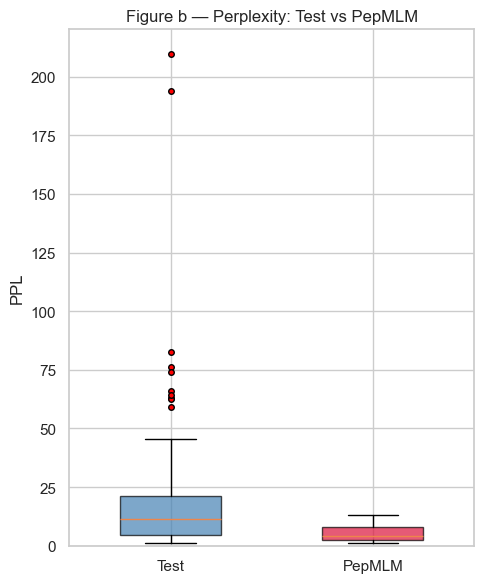

In [17]:
fig, ax = plt.subplots(figsize=(5, 6))

data_b = [
    test_results['PPL'].dropna().values,
    gen_df['ppl_gen'].values,
]
bp = ax.boxplot(data_b, labels=['Test', 'PepMLM'],
                patch_artist=True, widths=0.5,
                flierprops=dict(marker='o', markerfacecolor='red',
                                markersize=4, linestyle='none'))

colors = ['steelblue', 'crimson']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_ylabel('PPL', fontsize=12)
ax.set_title('Figure b — Perplexity: Test vs PepMLM', fontsize=12)
ax.set_ylim(0, None)
plt.tight_layout()
plt.savefig('../data/structures/fig_b_ppl_boxplot.jpg', dpi=150, bbox_inches='tight')
plt.show()

### Figure c — Density of log PPL

Replicates panel c. Adds a Random baseline (shuffled amino acids of same lengths).

In [ ]:
AA = list('ACDEFGHIKLMNPQRSTVWY')

def random_ppl(receptor_seq, pep_len):
    rand_pep = ''.join(random.choices(AA, k=pep_len))
    return compute_ppl(receptor_seq, rand_pep)

random_ppls = [random_ppl(row['Receptor Sequence'], len(row['Sequence']))
               for _, row in subset.iterrows()]

fig, ax = plt.subplots(figsize=(7, 5))

log_test  = np.log(test_results['PPL'].dropna() + 1e-6)
log_gen   = np.log(gen_df['ppl_gen'] + 1e-6)
log_rand  = np.log(np.array(random_ppls) + 1e-6)

sns.kdeplot(log_test, ax=ax, color='steelblue', fill=True, alpha=0.4, label='Test')
sns.kdeplot(log_gen,  ax=ax, color='crimson',   fill=True, alpha=0.4, label='PepMLM')
sns.kdeplot(log_rand, ax=ax, color='mediumpurple', fill=True, alpha=0.4, label='Random')

ax.set_xlabel('log PPL', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title('Figure c — log PPL Density: Test vs PepMLM vs Random', fontsize=12)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('../data/structures/fig_c_logppl_density.jpg', dpi=150, bbox_inches='tight')
plt.show()

### Figure e — PPL: PepMLM vs Permuted

Replicates panel e. Permuted sequences = same amino acids as generated, randomly shuffled — destroying the sequence-specific signal.

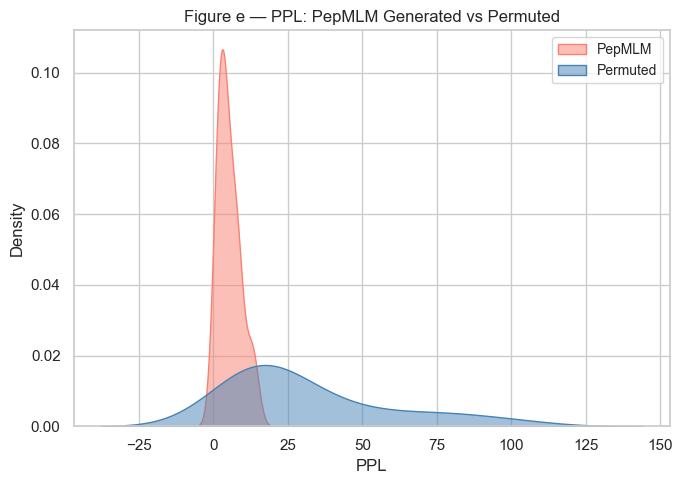

In [ ]:
def permuted_ppl(receptor_seq, peptide_seq):
    permuted = ''.join(random.sample(list(peptide_seq), len(peptide_seq)))
    return compute_ppl(receptor_seq, permuted)

perm_ppls = [permuted_ppl(row['Receptor Sequence'], r['gen_pep'])
             for (_, row), (_, r) in zip(subset.iterrows(), gen_df.iterrows())]

fig, ax = plt.subplots(figsize=(7, 5))
sns.kdeplot(gen_df['ppl_gen'], ax=ax, color='salmon',     fill=True, alpha=0.5, label='PepMLM')
sns.kdeplot(perm_ppls,         ax=ax, color='steelblue',  fill=True, alpha=0.5, label='Permuted')

ax.set_xlabel('PPL', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title('Figure e — PPL: PepMLM Generated vs Permuted', fontsize=12)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('../data/structures/fig_e_ppl_permuted.jpg', dpi=150, bbox_inches='tight')
plt.show()

### Figure g — Amino Acid Frequency

Replicates panel g. Test = true peptides from train set. PepMLM = our generated sequences.

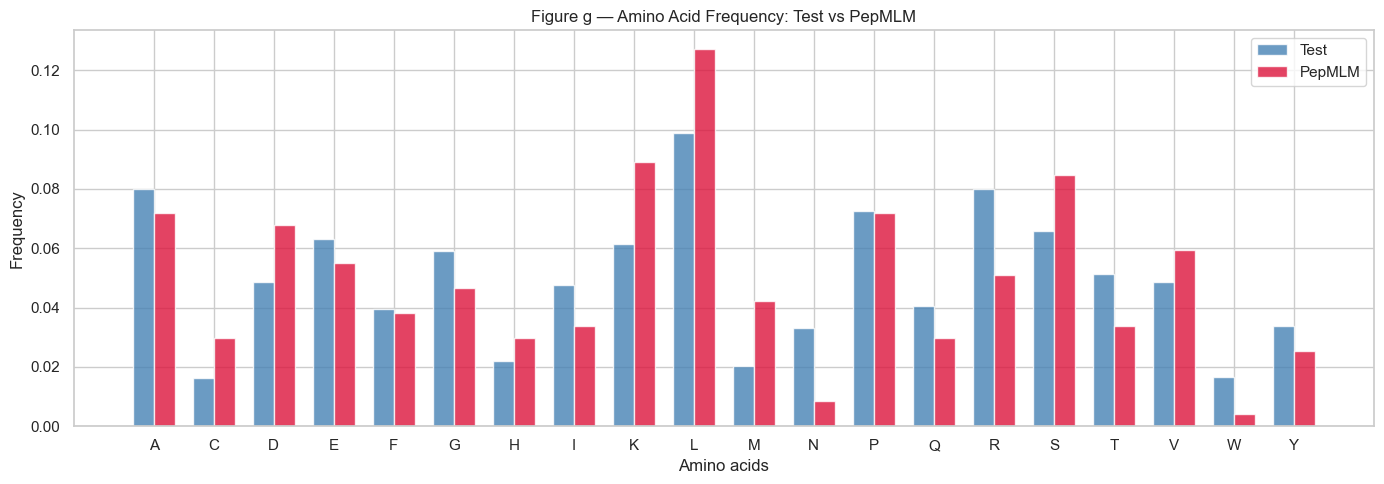

In [16]:
AA_ORDER = list('ACDEFGHIKLMNPQRSTVWY')

def aa_freq(sequences):
    counts = Counter(''.join(sequences))
    total  = sum(counts.get(a, 0) for a in AA_ORDER)
    return [counts.get(a, 0) / total for a in AA_ORDER]

freq_test = aa_freq(train_df['Sequence'].tolist())
freq_gen  = aa_freq(gen_df['gen_pep'].tolist())

x     = np.arange(len(AA_ORDER))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(x - width/2, freq_test, width, label='Test',   color='steelblue', alpha=0.8)
ax.bar(x + width/2, freq_gen,  width, label='PepMLM', color='crimson',   alpha=0.8)

ax.set_xticks(x)
ax.set_xticklabels(AA_ORDER, fontsize=11)
ax.set_xlabel('Amino acids', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_title('Figure g — Amino Acid Frequency: Test vs PepMLM', fontsize=12)
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('../data/structures/fig_g_aa_freq.jpg', dpi=150, bbox_inches='tight')
plt.show()